<a href="https://colab.research.google.com/github/Aaish48/Aaish48/blob/main/CV_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.1/977.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultra

Saving org.png to org.png
Image loaded successfully!


100%|██████████| 6.25M/6.25M [00:00<00:00, 66.5MB/s]



0: 480x640 26 cars, 503.2ms
Speed: 16.5ms preprocess, 503.2ms inference, 39.1ms postprocess per image at shape (1, 3, 480, 640)


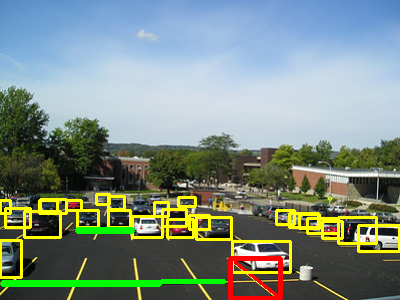

In [ ]:
# Install dependencies
!pip install -q ultralytics opencv-python numpy

# Import required libraries
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files
from ultralytics import YOLO

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name
frame = cv2.imread(image_path)

# Check if the image is loaded
if frame is None:
    print("Error: Could not load image. Please re-upload.")
else:
    print("Image loaded successfully!")

# Convert image to HSV color space
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

# Define yellow color range in HSV
lower_yellow = np.array([20, 100, 100])
upper_yellow = np.array([30, 255, 255])

# Mask to detect only yellow lines
yellow_mask = cv2.inRange(hsv, lower_yellow, upper_yellow)

# Detect edges in the yellow mask
edges = cv2.Canny(yellow_mask, 50, 150)

# Detect yellow parking lines using Hough Transform
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=5)

# Find parking spaces using detected yellow lines
parking_spaces = []
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        parking_spaces.append((x1, y1, x2 - x1, y2 - y1))
        cv2.line(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)  # Red lines for detected parking slots

# Load YOLOv8 model for car detection
yolo_model = YOLO('yolov8n.pt')

# Detect cars
results = yolo_model(frame)
cars_detected = []

for result in results:
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Get bounding box coordinates
        cars_detected.append((x1, y1, x2 - x1, y2 - y1))
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 2)  # Yellow rectangles for cars

# Function to check if a parking space is occupied
def is_occupied(parking_space, cars_detected):
    px, py, pw, ph = parking_space
    for (x, y, w, h) in cars_detected:
        if (x < px + pw and x + w > px) and (y < py + ph and y + h > py):
            return True
    return False

# Check occupancy and mark spaces
for space in parking_spaces:
    color = (0, 255, 0) if not is_occupied(space, cars_detected) else (0, 0, 255)  # Green = empty, Red = occupied
    cv2.rectangle(frame, (space[0], space[1]), (space[0] + space[2], space[1] + space[3]), color, 3)

# Show the final image with detections
cv2_imshow(frame)
